<a href="https://colab.research.google.com/github/jingxuchen19/ECON5200-Applied-Data-Analytics-in-Economics/blob/main/Assignment_5/Econ_5200_Assignment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install wbgapi scikit-learn statsmodels matplotlib seaborn numpy pandas

In [2]:
import wbgapi as wb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, LogisticRegression, lasso_path
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (confusion_matrix, classification_report, roc_curve,
                             roc_auc_score, precision_recall_curve, f1_score,
                             precision_score, recall_score)
import statsmodels.api as sm

In [3]:
# indicator dictionary from Lab 16 (37 indicators)
indicators = {
    'NY.GDP.PCAP.KD.ZG': 'gdp_growth_pc',
    'NE.TRD.GNFS.ZS':    'trade_pct_gdp',
    'BX.KLT.DINV.WD.GD.ZS': 'fdi_inflows_pct_gdp',
    'TM.TAX.MRCH.SM.AR.ZS': 'tariff_rate_avg',
    'BX.GSR.ROYL.CD':    'royalties_receipts',
    'FP.CPI.TOTL.ZG':    'inflation_cpi',
    'GC.DOD.TOTL.GD.ZS': 'govt_debt_pct_gdp',
    'GC.XPN.TOTL.GD.ZS': 'govt_expenditure_pct_gdp',
    'BN.CAB.XOKA.GD.ZS': 'current_account_pct_gdp',
    'FR.INR.RINR':       'real_interest_rate',
    'PA.NUS.FCRF':       'exchange_rate_official',
    'SE.SEC.ENRR':       'secondary_enrollment_gross',
    'SE.TER.ENRR':       'tertiary_enrollment_gross',
    'SE.ADT.LITR.ZS':    'adult_literacy_rate',
    'SE.XPD.TOTL.GD.ZS': 'education_expenditure_pct_gdp',
    'SL.UEM.TOTL.ZS':    'unemployment_rate',
    'IT.NET.USER.ZS':    'internet_users_pct',
    'IT.CEL.SETS.P2':    'mobile_subscriptions_per100',
    'EG.ELC.ACCS.ZS':    'electricity_access_pct',
    'IS.ROD.PAVE.ZS':    'paved_roads_pct',
    'SP.DYN.LE00.IN':    'life_expectancy',
    'SH.DYN.MORT':       'infant_mortality_per1000',
    'SP.POP.GROW':       'population_growth',
    'SP.URB.TOTL.IN.ZS': 'urbanization_pct',
    'SH.XPD.CHEX.GD.ZS': 'health_expenditure_pct_gdp',
    'FS.AST.DOMS.GD.ZS': 'domestic_credit_pct_gdp',
    'CM.MKT.LCAP.GD.ZS': 'market_cap_pct_gdp',
    'FB.ATM.TOTL.P5':    'atms_per100k',
    'FD.AST.PRVT.GD.ZS': 'private_credit_pct_gdp',
    'NY.GDP.TOTL.RT.ZS': 'natural_resource_rents_pct_gdp',
    'EG.FEC.RNEW.ZS':    'renewable_energy_pct',
    'EN.ATM.CO2E.PC':    'co2_emissions_per_capita',
    'NV.AGR.TOTL.ZS':    'agriculture_pct_gdp',
    'AG.LND.ARBL.ZS':    'arable_land_pct',
    'IQ.CPA.TRAD.XQ':    'trade_cpia',
    'IQ.CPA.FINS.XQ':    'financial_management_cpia',
    'IQ.CPA.PROP.XQ':    'property_rights_cpia',
}
print(f"Total indicators: {len(indicators)}")

Total indicators: 37


In [4]:
# download from World Bank API (2013-2019)
raw = wb.data.DataFrame(list(indicators.keys()), time=range(2013, 2020), skipBlanks=True, labels=False)
raw.columns = [indicators[c] if c in indicators else c for c in raw.columns]
print(f"Raw data shape: {raw.shape}")

Raw data shape: (7211, 7)


In [5]:
# collapse to country-level means
if isinstance(raw.index, pd.MultiIndex):
    country_data = raw.mean(axis=1).unstack(level='series')
    country_data = country_data.rename(columns=indicators)
else:
    country_data = raw.copy()

# drop countries missing >40% of indicators
country_data = country_data.dropna(thresh=int(0.6 * country_data.shape[1]))

# drop indicators missing >40% of countries
country_data = country_data.dropna(axis=1, thresh=int(0.6 * len(country_data)))

# median-impute remaining gaps
country_data = country_data.fillna(country_data.median())

print(f"Clean dataset: {len(country_data)} countries x {country_data.shape[1]} indicators")

Clean dataset: 238 countries x 29 indicators


In [6]:
# continuous outcome
y_cont = country_data['gdp_growth_pc']

# binary crisis outcome: 1 if negative average growth
country_data['crisis'] = (country_data['gdp_growth_pc'] < 0).astype(int)
y_class = country_data['crisis']

# features = everything except gdp_growth_pc and crisis
X = country_data.drop(columns=['gdp_growth_pc', 'crisis'])

print(f"Final dataset: {X.shape[0]} countries, {X.shape[1]} features")
print(f"Crisis: {y_class.sum()}, Non-crisis: {(y_class == 0).sum()}")
print(f"Crisis base rate: {y_class.mean():.3f}")

Final dataset: 238 countries, 28 features
Crisis: 38, Non-crisis: 200
Crisis base rate: 0.160


In [7]:
# 70/30 split
X_train, X_test, y_train_cont, y_test_cont = train_test_split(X, y_cont, test_size=0.3, random_state=42)
_, _, y_train_class, y_test_class = train_test_split(X, y_class, test_size=0.3, random_state=42)

# standardize - fit on training only
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test.index)

print(f"Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}")

Train: (166, 28), Test: (72, 28)


**Phase 1: The Complexity Trap — OLS Failure and Regularization Rescue**

Step 1.1: Demonstrating OLS Overfitting

In [8]:
# OLS on all predictors to forecast gdp_growth_pc
ols = LinearRegression()
ols.fit(X_train_scaled, y_train_cont)

# Training and Test R²
train_r2 = ols.score(X_train_scaled, y_train_cont)
test_r2 = ols.score(X_test_scaled, y_test_cont)

print(f"Training R²: {train_r2:.3f}")
print(f"Test R²: {test_r2:.3f}")
print(f"Train-Test R² gap: {train_r2 - test_r2:.3f}")
print(f"p/n ratio: {X_train_scaled.shape[1]}/{X_train_scaled.shape[0]} = {X_train_scaled.shape[1]/X_train_scaled.shape[0]:.3f}")

Training R²: 0.603
Test R²: -0.914
Train-Test R² gap: 1.517
p/n ratio: 28/166 = 0.169


**Step 1.1 Written Response**

The p/n ratio is 28/166 = 0.169, which means OLS has a lot of predictors relative to the sample, leaving fewer degrees of freedom and making it easy to fit noise. That's why we see a Training R² of 0.603 but a Test R² of -0.914, high variance, low bias. OLS overfits because it doesn't penalize complexity at all.

Step 1.2: Ridge and Lasso to the Rescue

In [9]:
# Ridge with 5-fold CV
ridge = RidgeCV(alphas=np.logspace(-2, 3, 50), cv=5)
ridge.fit(X_train_scaled, y_train_cont)

print("RIDGE:")
print(f"  CV-selected lambda: {ridge.alpha_:.4f}")
print(f"  Non-zero coefs: {np.sum(ridge.coef_ != 0)} of {X_train_scaled.shape[1]}")
print(f"  Training R²: {ridge.score(X_train_scaled, y_train_cont):.3f}")
print(f"  Test R²: {ridge.score(X_test_scaled, y_test_cont):.3f}")

RIDGE:
  CV-selected lambda: 47.1487
  Non-zero coefs: 28 of 28
  Training R²: 0.559
  Test R²: -0.068


In [10]:
# LassoCV with 5-fold CV
lasso = LassoCV(cv=5, max_iter=10000, random_state=42)
lasso.fit(X_train_scaled, y_train_cont)

print("LASSO:")
print(f"  CV-selected lambda: {lasso.alpha_:.4f}")
print(f"  Non-zero coefs: {np.sum(lasso.coef_ != 0)} of {X_train_scaled.shape[1]}")
print(f"  Training R²: {lasso.score(X_train_scaled, y_train_cont):.3f}")
print(f"  Test R²: {lasso.score(X_test_scaled, y_test_cont):.3f}")

LASSO:
  CV-selected lambda: 0.0660
  Non-zero coefs: 18 of 28
  Training R²: 0.573
  Test R²: -0.355


In [11]:
# model comparison table
from sklearn.metrics import r2_score, mean_squared_error

comparison = pd.DataFrame({
    'Method': ['OLS', 'Ridge', 'Lasso'],
    'Lambda': ['N/A', f'{ridge.alpha_:.4f}', f'{lasso.alpha_:.4f}'],
    'Non-zero Predictors': [X_train_scaled.shape[1], np.sum(ridge.coef_ != 0), np.sum(lasso.coef_ != 0)],
    'Training R²': [train_r2, ridge.score(X_train_scaled, y_train_cont), lasso.score(X_train_scaled, y_train_cont)],
    'Test R²': [test_r2, ridge.score(X_test_scaled, y_test_cont), lasso.score(X_test_scaled, y_test_cont)],
    'Test RMSE': [
        np.sqrt(mean_squared_error(y_test_cont, ols.predict(X_test_scaled))),
        np.sqrt(mean_squared_error(y_test_cont, ridge.predict(X_test_scaled))),
        np.sqrt(mean_squared_error(y_test_cont, lasso.predict(X_test_scaled)))
    ]
})
print(comparison.to_string(index=False))

Method  Lambda  Non-zero Predictors  Training R²   Test R²  Test RMSE
   OLS     N/A                   28     0.603380 -0.914092   2.922676
 Ridge 47.1487                   28     0.559344 -0.068104   2.183262
 Lasso  0.0660                   18     0.573420 -0.355164   2.459207


**Step 1.2 Written Response**

I'd recommend Ridge for operational forecasting. It shrinks all coefficients toward zero, which adds a bit of bias but cuts variance a lot — Test R² goes from -0.914 (OLS) to -0.068. Lasso adds even more bias by zeroing out 10 predictors entirely, which helps interpretability but hurts prediction here since the WDI indicators are correlated and Lasso struggles to pick between them.

Step 1.3: The Lasso Path — Which Indicators Enter First?

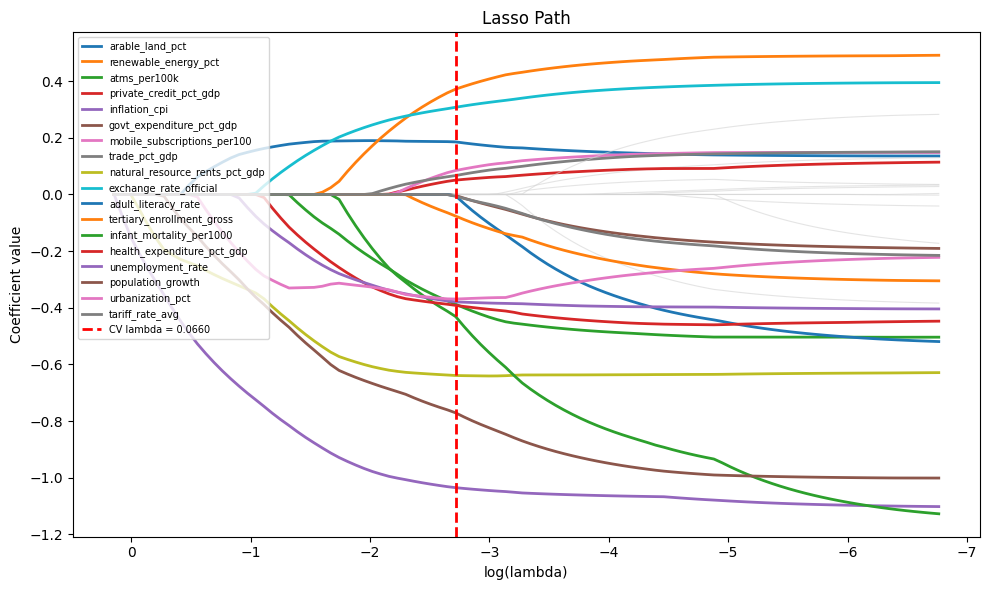

In [12]:
# Lasso path
alphas_path, coefs_path, _ = lasso_path(X_train_scaled, y_train_cont, eps=1e-3, n_alphas=100)

fig, ax = plt.subplots(figsize=(10, 6))

# color non-zero features at CV lambda, gray the rest
active = np.where(lasso.coef_ != 0)[0]
for i in range(coefs_path.shape[0]):
    if i in active:
        ax.plot(np.log(alphas_path), coefs_path[i], linewidth=2, label=X.columns[i])
    else:
        ax.plot(np.log(alphas_path), coefs_path[i], linewidth=0.8, color='lightgray', alpha=0.6)

# vertical dashed line at CV-selected lambda
ax.axvline(np.log(lasso.alpha_), color='red', linestyle='--', linewidth=2, label=f'CV lambda = {lasso.alpha_:.4f}')
ax.set_xlabel('log(lambda)')
ax.set_ylabel('Coefficient value')
ax.set_title('Lasso Path')
ax.legend(loc='upper left', fontsize=7)
ax.invert_xaxis()
plt.tight_layout()
plt.show()

In [13]:
# find the first predictor to enter (leaves zero at highest lambda)
first_nonzero_alpha = []
for i in range(coefs_path.shape[0]):
    nonzero_idx = np.where(coefs_path[i] != 0)[0]
    if len(nonzero_idx) > 0:
        first_nonzero_alpha.append((X.columns[i], alphas_path[nonzero_idx[0]]))

first_nonzero_alpha.sort(key=lambda x: x[1], reverse=True)
print("First predictor to enter the model:")
print(f"  {first_nonzero_alpha[0][0]} at lambda = {first_nonzero_alpha[0][1]:.4f}")

First predictor to enter the model:
  inflation_cpi at lambda = 1.0762


**Step 1.3 Written Response**

Inflation_cpi enters first at lambda = 1.0762, that makes sense. High inflation directly hurts real growth, so it's the strongest standalone predictor.
The colleague is wrong. Lasso zeroing out life_expectancy doesn't mean health is irrelevant, it just means it's conditionally predictively redundant. Life expectancy is correlated with things like infant_mortality and electricity_access that are already in the model, so Lasso drops it. That's about correlation structure, not economic importance.

**Phase 2: The Crisis Classifier — From Forecasting to Classification**

Step 2.1: The Linear Probability Model — Exposing the Failure

In [14]:
# LPM using Lasso-selected features
lasso_features = X.columns[lasso.coef_ != 0]
print(f"Lasso-selected features: {len(lasso_features)}")

lpm = LinearRegression()
lpm.fit(X_train_scaled[lasso_features], y_train_class)

# predicted values on test set
lpm_preds = lpm.predict(X_test_scaled[lasso_features])

# count how many fall outside [0, 1]
below_0 = np.sum(lpm_preds < 0)
above_1 = np.sum(lpm_preds > 1)
print(f"Predictions below 0: {below_0}")
print(f"Predictions above 1: {above_1}")
print(f"Min: {lpm_preds.min():.3f}, Max: {lpm_preds.max():.3f}")

Lasso-selected features: 18
Predictions below 0: 13
Predictions above 1: 1
Min: -0.301, Max: 1.568


**Step 2.1 Written Response**

Predicted probabilities outside [0, 1] aren't just a cosmetic issue. They're meaningless. 13 predictions fell below 0 and 1 went above 1. If the IMF gets a "-12% probability of crisis" for a country, that's uninterpretable, you can't have a negative chance of something happening. It means the LPM is treating probability as a linear function, which just doesn't work for binary outcomes.

Step 2.2: Logistic Regression — The Sigmoid Fix

In [15]:
# Logistic Regression on Lasso-selected features
logit = LogisticRegression(max_iter=10000)
logit.fit(X_train_scaled[lasso_features], y_train_class)

# coefficients and intercept
print(f"Intercept: {logit.intercept_[0]:.4f}")
print()

# odds ratio table
coef_df = pd.DataFrame({
    'Feature': lasso_features,
    'Coefficient': logit.coef_[0],
    'Odds Ratio': np.exp(logit.coef_[0])
})
coef_df['Abs OR'] = np.abs(coef_df['Odds Ratio'])
coef_df = coef_df.sort_values('Abs OR', ascending=False)
print(coef_df[['Feature', 'Coefficient', 'Odds Ratio']].to_string(index=False))

Intercept: -3.0262

                       Feature  Coefficient  Odds Ratio
             population_growth     0.825074    2.282050
    health_expenditure_pct_gdp     0.822688    2.276612
      infant_mortality_per1000     0.743399    2.103072
natural_resource_rents_pct_gdp     0.729249    2.073522
               tariff_rate_avg     0.578947    1.784159
             unemployment_rate     0.532429    1.703064
                 inflation_cpi     0.494075    1.638982
                  atms_per100k     0.368015    1.444864
   mobile_subscriptions_per100     0.356114    1.427771
           adult_literacy_rate     0.273696    1.314814
              urbanization_pct     0.211874    1.235992
      govt_expenditure_pct_gdp     0.131039    1.140012
        exchange_rate_official    -0.014787    0.985322
     tertiary_enrollment_gross    -0.073789    0.928867
        private_credit_pct_gdp    -0.078833    0.924194
                 trade_pct_gdp    -0.353088    0.702515
          renewable_energy_p

In [16]:
# verify predicted probabilities are in [0, 1]
logit_probs = logit.predict_proba(X_test_scaled[lasso_features])[:, 1]
print(f"Min probability: {logit_probs.min():.4f}")
print(f"Max probability: {logit_probs.max():.4f}")

Min probability: 0.0002
Max probability: 0.9999


**Step 2.2 Written Response**

Population_growth has the largest absolute odds ratio of 2.28. A one standard-deviation increase in population growth multiplies the odds of crisis by 2.28, holding all else constant. In plain terms, countries with faster population growth are more than twice as likely to experience a growth crisis, possibly because rapid population growth can outpace economic output and strain resources.

Step 2.3: Side-by-Side Visualization — LPM vs. Logistic

Strongest predictor: population_growth


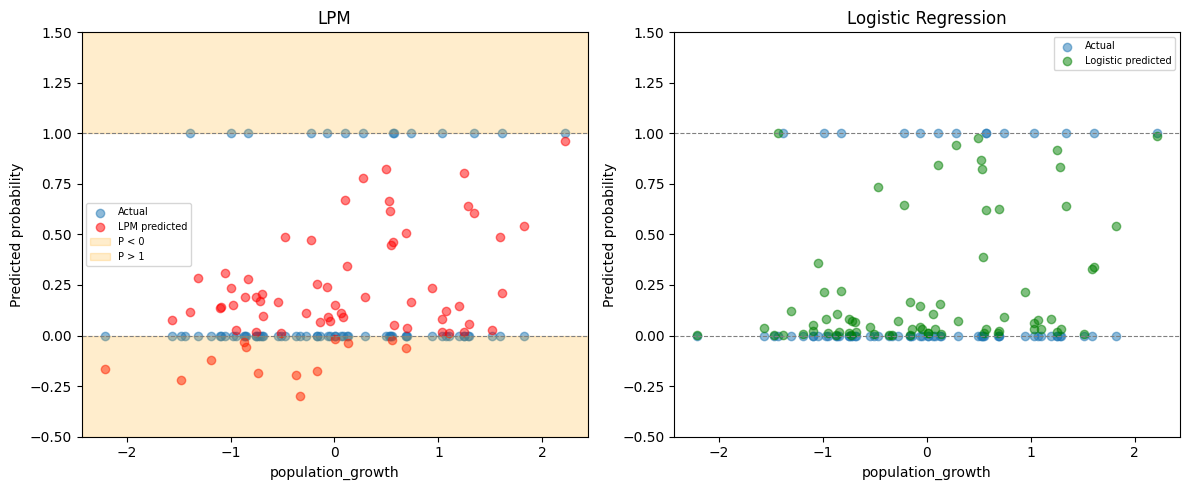

In [17]:
# LPM vs Logistic side-by-side
# strongest predictor = ;argest absolute odds ratio
strongest = coef_df.iloc[0]['Feature']
print(f"Strongest predictor: {strongest}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# x values for plotting
x_test_feat = X_test_scaled[strongest]
x_range = np.linspace(x_test_feat.min() - 1, x_test_feat.max() + 1, 200)

# LPM panel
ax1.scatter(x_test_feat, y_test_class, alpha=0.5, label='Actual')
ax1.scatter(x_test_feat, lpm_preds, alpha=0.5, color='red', label='LPM predicted')
# shade impossible regions
ax1.axhspan(-0.5, 0, color='orange', alpha=0.2, label='P < 0')
ax1.axhspan(1, 1.5, color='orange', alpha=0.2, label='P > 1')
ax1.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax1.axhline(1, color='gray', linestyle='--', linewidth=0.8)
ax1.set_xlabel(strongest)
ax1.set_ylabel('Predicted probability')
ax1.set_title('LPM')
ax1.legend(fontsize=7)
ax1.set_ylim(-0.5, 1.5)

# Logistic panel
ax2.scatter(x_test_feat, y_test_class, alpha=0.5, label='Actual')
ax2.scatter(x_test_feat, logit_probs, alpha=0.5, color='green', label='Logistic predicted')
ax2.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax2.axhline(1, color='gray', linestyle='--', linewidth=0.8)
ax2.set_xlabel(strongest)
ax2.set_ylabel('Predicted probability')
ax2.set_title('Logistic Regression')
ax2.legend(fontsize=7)
ax2.set_ylim(-0.5, 1.5)

plt.tight_layout()
plt.show()

**Phase 3: Operational Deployment — Metrics That Matter**

Step 3.1: The Accuracy Paradox

In [18]:
# Naive baseline vs logistic at threshold 0.5
# naive baseline: always predict "no crisis"
naive_acc = (y_test_class == 0).mean()
naive_recall = 0.0 # catches zero crises

# logistic at default threshold 0.5
logit_preds_05 = (logit_probs >= 0.5).astype(int)
logit_acc = (logit_preds_05 == y_test_class).mean()
logit_recall = recall_score(y_test_class, logit_preds_05)

print(f"Naive baseline accuracy: {naive_acc:.3f}")
print(f"Naive baseline recall on crisis: {naive_recall:.3f}")
print()
print(f"Logistic (t=0.5) accuracy: {logit_acc:.3f}")
print(f"Logistic (t=0.5) recall on crisis: {logit_recall:.3f}")

Naive baseline accuracy: 0.806
Naive baseline recall on crisis: 0.000

Logistic (t=0.5) accuracy: 0.764
Logistic (t=0.5) recall on crisis: 0.429


**Step 3.1 Written Response**

She'd be misled. The naive baseline gets 80.6% accuracy by just always predicting "no crisis", but it catches zero actual crises. Our logistic model at t=0.5 has lower accuracy (76.4%) but actually catches 42.9% of crises. With only 19.4% of countries in crisis, accuracy is dominated by the majority class and tells you almost nothing about how well you detect the thing you actually care about.

Step 3.2 — Confusion Matrix + Classification Report

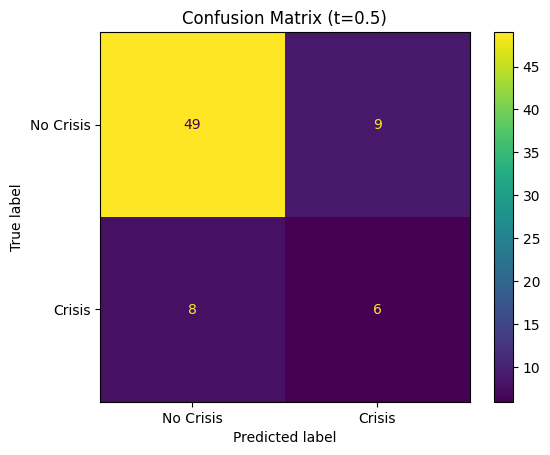

              precision    recall  f1-score   support

   No Crisis       0.86      0.84      0.85        58
      Crisis       0.40      0.43      0.41        14

    accuracy                           0.76        72
   macro avg       0.63      0.64      0.63        72
weighted avg       0.77      0.76      0.77        72

True Positives (crises correctly flagged): 6
False Negatives (crises missed): 8
False Positives (false alarms): 9
True Negatives: 49


In [19]:
from sklearn.metrics import ConfusionMatrixDisplay

# confusion matrix display
ConfusionMatrixDisplay.from_predictions(y_test_class, logit_preds_05,
                                        display_labels=['No Crisis', 'Crisis'])
plt.title('Confusion Matrix (t=0.5)')
plt.show()

# classification report
print(classification_report(y_test_class, logit_preds_05, target_names=['No Crisis', 'Crisis']))

# extract TP, FN, FP, TN
cm = confusion_matrix(y_test_class, logit_preds_05)
tn, fp, fn, tp = cm.ravel()
print(f"True Positives (crises correctly flagged): {tp}")
print(f"False Negatives (crises missed): {fn}")
print(f"False Positives (false alarms): {fp}")
print(f"True Negatives: {tn}")

**Step 3.2 Written Response**

A False Negative is way more costly. Missing a real crisis costs 50 billion dollars in contagion, while a False Positive only wastes $2 million on an unnecessary mission. That's a 25,000x asymmetry. So the Division Chief should prioritize Recall over Precision, because the cost of missing a crisis far outweighs the cost of a false alarm.

Step 3.3: ROC and Precision-Recall Curves

/tmp/ipykernel_17414/1062514194.py:15: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  pr_auc = np.trapz(prec[::-1], rec[::-1])


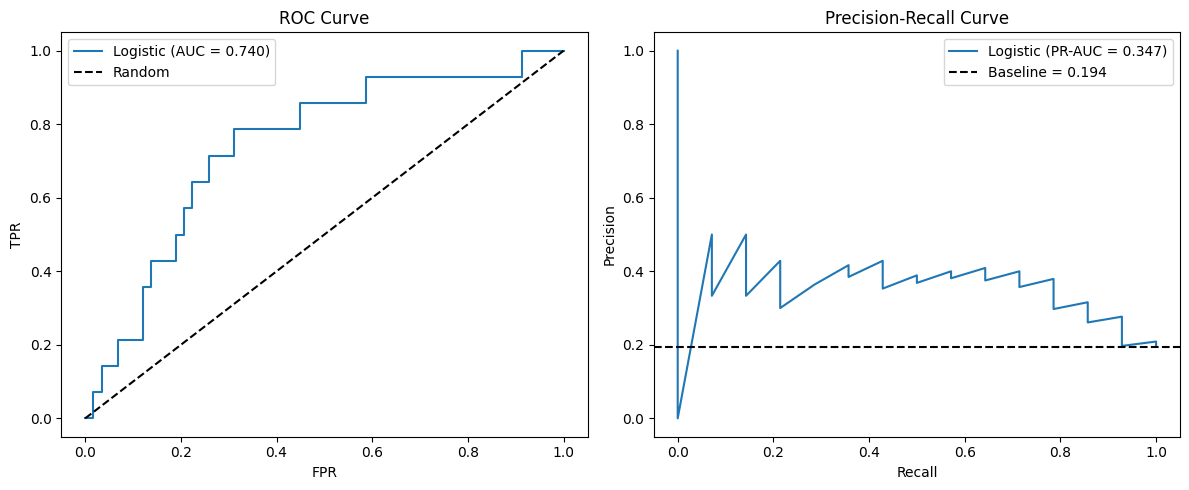

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# ROC curve
fpr, tpr, _ = roc_curve(y_test_class, logit_probs)
auc_score = roc_auc_score(y_test_class, logit_probs)
ax1.plot(fpr, tpr, label=f'Logistic (AUC = {auc_score:.3f})')
ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('FPR')
ax1.set_ylabel('TPR')
ax1.set_title('ROC Curve')
ax1.legend()

# Precision-Recall curve
prec, rec, _ = precision_recall_curve(y_test_class, logit_probs)
pr_auc = np.trapz(prec[::-1], rec[::-1])
baseline = y_test_class.mean()
ax2.plot(rec, prec, label=f'Logistic (PR-AUC = {pr_auc:.3f})')
ax2.axhline(baseline, color='k', linestyle='--', label=f'Baseline = {baseline:.3f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve')
ax2.legend()

plt.tight_layout()
plt.show()

**Step 3.3 Written Response**

ROC-AUC is 0.740 but PR-AUC is only 0.347. The gap is because ROC-AUC gets inflated by all the True Negatives (non-crisis countries we correctly ignore), while PR-AUC focuses only on how well we handle the positive class. Since the IMF's whole job here is detecting the rare crisis countries, the PR curve is more informative for this mission.

Step 3.4: Threshold Analysis — The 5-Mission Constraint

In [21]:
thresholds = np.arange(0.01, 1.00, 0.01)
results = []
for t in thresholds:
    preds = (logit_probs >= t).astype(int)
    n_flagged = preds.sum()
    p = precision_score(y_test_class, preds, zero_division=0)
    r = recall_score(y_test_class, preds, zero_division=0)
    f1 = f1_score(y_test_class, preds, zero_division=0)
    results.append([t, n_flagged, p, r, f1])

res_df = pd.DataFrame(results, columns=['Threshold', 'Flagged', 'Precision', 'Recall', 'F1'])

# capacity-constrained, lowest threshold that flags at most 5
capacity = res_df[res_df['Flagged'] <= 5].iloc[0]
print("Capacity-constrained threshold (max 5 missions):")
print(f"  Threshold: {capacity['Threshold']:.2f}")
print(f"  Flagged: {int(capacity['Flagged'])}")
print(f"  Precision: {capacity['Precision']:.3f}")
print(f"  Recall: {capacity['Recall']:.3f}")

# F1-optimal threshold
f1_best = res_df.loc[res_df['F1'].idxmax()]
print(f"\nF1-optimal threshold: {f1_best['Threshold']:.2f}")
print(f"  F1: {f1_best['F1']:.3f}")

Capacity-constrained threshold (max 5 missions):
  Threshold: 0.88
  Flagged: 5
  Precision: 0.400
  Recall: 0.143

F1-optimal threshold: 0.13
  F1: 0.513


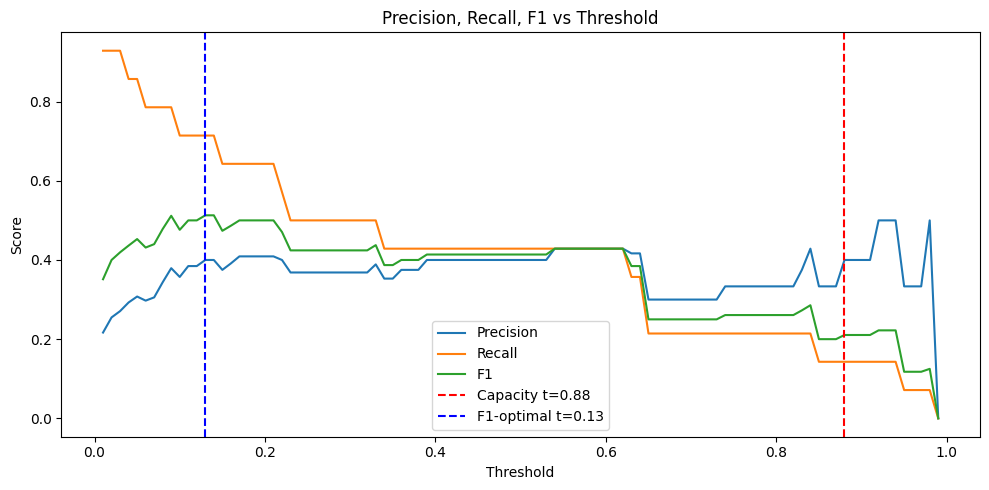

In [22]:
# plot precision, recall, F1 vs threshold
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(res_df['Threshold'], res_df['Precision'], label='Precision')
ax.plot(res_df['Threshold'], res_df['Recall'], label='Recall')
ax.plot(res_df['Threshold'], res_df['F1'], label='F1')
ax.axvline(capacity['Threshold'], color='red', linestyle='--', label=f"Capacity t={capacity['Threshold']:.2f}")
ax.axvline(f1_best['Threshold'], color='blue', linestyle='--', label=f"F1-optimal t={f1_best['Threshold']:.2f}")
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision, Recall, F1 vs Threshold')
ax.legend()
plt.tight_layout()
plt.show()

**Step 3.4 Written Response**

I'd recommend the F1-optimal threshold of t=0.13 over the capacity-constrained t=0.88. At t=0.88, we only flag 5 countries but catch just 1 out of 14 crises (Recall = 0.143). That means we'd miss 13 crises, which is unacceptable given the $50B cost per miss. At t=0.13, we flag more countries and catch a much larger share of crises. The tradeoff is more false alarms and exceeding the 5-mission cap, but given the massive cost asymmetry, it's better to over-deploy assessment teams than to let a sovereign default slip through.

**Phase 4: AI Context Engineering (The P.R.I.M.E. Framework)**

Task 4.1: Bootstrap Confidence Intervals for the Lasso Path

**P.R.I.M.E. Prompt for Task 4.1: Bootstrap Lasso Selection Frequency**

**Prep:** I have a standardized training set (X_train_scaled, y_train_cont) with 28 predictors and 166 observations. I already fit a LassoCV model.

**Request:** Write a Python script that:
1. Draws 200 bootstrap resamples (with replacement) from the training data
2. Fits LassoCV on each resample and records which features get non-zero coefficients
3. Computes the selection frequency for each predictor (fraction of times Lasso picks it)
4. Produces a horizontal bar chart ranking predictors by selection frequency, with a vertical reference line at 50%

**Iterate:** Use random_state=42 for reproducibility. Keep the code simple and use only sklearn and matplotlib.

**Mechanism Check:** Each bootstrap resample changes which countries are in the sample, so correlated predictors may swap in and out — this reveals which ones are truly stable vs. which ones are interchangeable.

**Evaluate:** I'll check that the chart clearly shows stable (>80%) vs fragile (<30%) predictors.

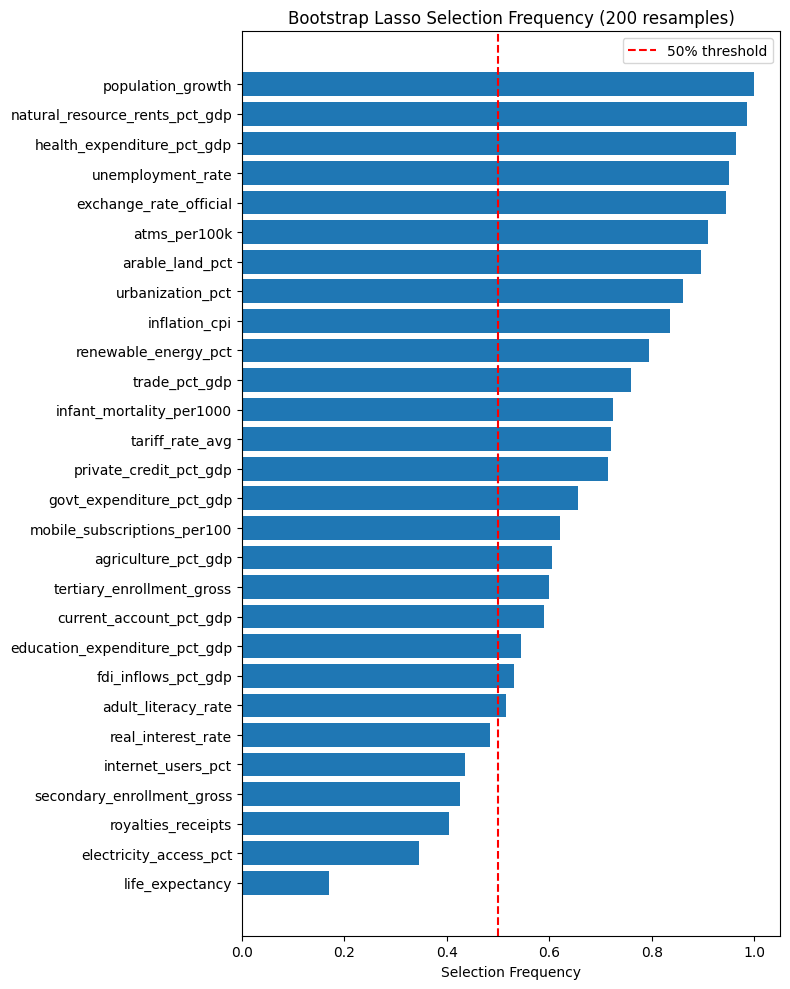

Stable (>80%):
['inflation_cpi', 'urbanization_pct', 'arable_land_pct', 'atms_per100k', 'exchange_rate_official', 'unemployment_rate', 'health_expenditure_pct_gdp', 'natural_resource_rents_pct_gdp', 'population_growth']

Fragile (<30%):
['life_expectancy']


In [23]:
# Task 4.1: Bootstrap Lasso selection frequency
np.random.seed(42)
n_boot = 200
selection_counts = np.zeros(X_train_scaled.shape[1])

for i in range(n_boot):
    idx = np.random.choice(len(X_train_scaled), size=len(X_train_scaled), replace=True)
    X_boot = X_train_scaled.iloc[idx]
    y_boot = y_train_cont.iloc[idx]
    lasso_boot = LassoCV(cv=5, max_iter=10000, random_state=42)
    lasso_boot.fit(X_boot, y_boot)
    selection_counts += (lasso_boot.coef_ != 0).astype(int)

# selection frequency
sel_freq = selection_counts / n_boot
freq_df = pd.DataFrame({'Feature': X.columns, 'Selection Frequency': sel_freq})
freq_df = freq_df.sort_values('Selection Frequency')

# horizontal bar chart
fig, ax = plt.subplots(figsize=(8, 10))
ax.barh(freq_df['Feature'], freq_df['Selection Frequency'])
ax.axvline(0.5, color='red', linestyle='--', label='50% threshold')
ax.set_xlabel('Selection Frequency')
ax.set_title('Bootstrap Lasso Selection Frequency (200 resamples)')
ax.legend()
plt.tight_layout()
plt.show()

# print stable and fragile
print("Stable (>80%):")
print(freq_df[freq_df['Selection Frequency'] > 0.8]['Feature'].tolist())
print("\nFragile (<30%):")
print(freq_df[freq_df['Selection Frequency'] < 0.3]['Feature'].tolist())

**Task 4.1 Written Response**

Stable predictors (>80%) include inflation_cpi, urbanization_pct, arable_land_pct, atms_per100k, exchange_rate_official, unemployment_rate, and health_expenditure_pct_gdp — Lasso picks these in almost every resample. The only fragile predictor (<30%) is life_expectancy, which makes sense since it's highly correlated with other development indicators like infant_mortality that are already stable selections. The instability shows that correlated WDI indicators swap in and out across bootstrap samples. Lasso only needs one from each correlated group.

Task 4.2: Cost-Sensitive Threshold Optimization

**P.R.I.M.E. Prompt for Task 4.2: Cost-Sensitive Threshold Optimization**

**Prep:** I have logistic regression predicted probabilities (logit_probs) and true labels (y_test_class) for 72 test countries. A missed crisis (FN) costs 50 billion dollars, a false alarm (FP) costs 2 million dollars.

**Request:** Write a Python script that:
1. Sweeps thresholds from 0.01 to 0.99
2. At each threshold, computes total expected cost: FN x 50B + FP x 2M
3. Plots the expected cost curve as a function of threshold
4. Identifies and annotates the cost-minimizing threshold

**Iterate:** Keep the code simple, use matplotlib for the plot.

**Mechanism Check:** Because FN costs 25,000x more than FP, the optimal threshold should be much lower than 0.5 — the model should be aggressive about flagging potential crises.

**Evaluate:** I'll compare the cost-minimizing threshold to the F1-optimal (0.13) and capacity-constrained (0.88) thresholds from Phase 3.

Cost-minimizing threshold: 0.03
Minimum expected cost: $50.07 billion


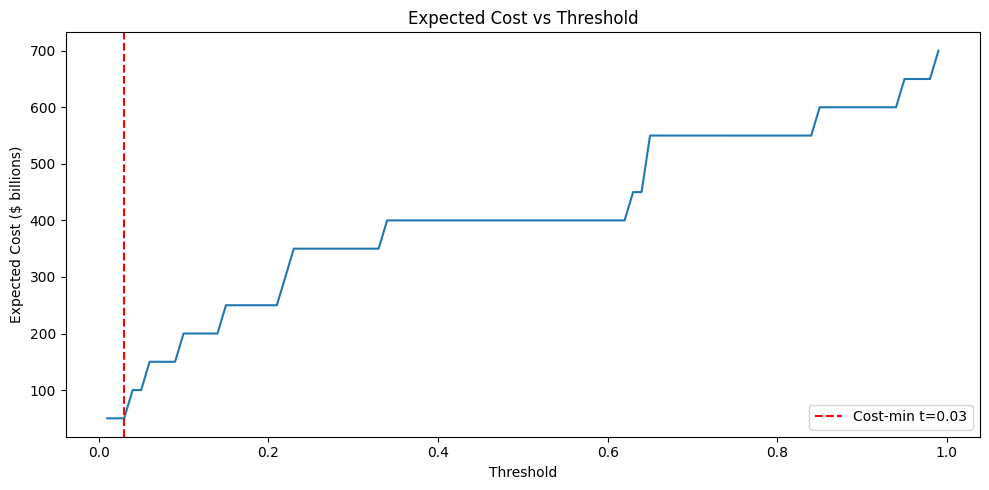

In [24]:
# Task 4.2: Cost-sensitive threshold optimization
cost_fn = 50e9   # $50 billion per missed crisis
cost_fp = 2e6    # $2 million per false alarm

thresholds = np.arange(0.01, 1.00, 0.01)
costs = []

for t in thresholds:
    preds = (logit_probs >= t).astype(int)
    cm_t = confusion_matrix(y_test_class, preds)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    total_cost = fn_t * cost_fn + fp_t * cost_fp
    costs.append(total_cost)

costs = np.array(costs)

# find cost-minimizing threshold
best_idx = np.argmin(costs)
best_t = thresholds[best_idx]
best_cost = costs[best_idx]

print(f"Cost-minimizing threshold: {best_t:.2f}")
print(f"Minimum expected cost: ${best_cost/1e9:.2f} billion")

# plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, costs / 1e9)
ax.axvline(best_t, color='red', linestyle='--', label=f'Cost-min t={best_t:.2f}')
ax.set_xlabel('Threshold')
ax.set_ylabel('Expected Cost ($ billions)')
ax.set_title('Expected Cost vs Threshold')
ax.legend()
plt.tight_layout()
plt.show()

**Task 4.2 Written Response**

The cost-minimizing threshold is t = 0.03, which is even lower than the F1-optimal t = 0.13 and far below the capacity-constrained t = 0.88. This makes sense because a missed crisis is 25,000 times more expensive than a false alarm, so the model should use a very low threshold to catch as many crises as possible. I would recommend the cost-minimizing threshold t = 0.03 for the IMF because it directly reflects the real-world cost asymmetry. The F1-optimal threshold treats precision and recall more symmetrically, which does not fit the IMF’s setting where missing a crisis is dramatically more costly than issuing a false alarm.